# RadioML 2016.10a Modulation Dataset Classification

## 1. Download and load the dataset

In [89]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [100]:
import torch

import pickle
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

path = kagglehub.dataset_download("nolasthitnotomorrow/radioml2016-deepsigcom")
print("Path to dataset files:", path)

pkl_path = f"{path}/RML2016.10a_dict.pkl"

with open(pkl_path, "rb") as f:
    df = pickle.load(f, encoding="latin1")

Path to dataset files: /Users/daniel/.cache/kagglehub/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/versions/1


## 2. Data exploration

In [91]:
# The dataset is structured in this way:
# {(mods, snrs): [frames, I/Qs, samples]}
# {(  11,   20): [  1000,    2,     128]}

keys = df.keys()
mods, snrs = zip(*keys)

unique_mods = np.unique(mods)
unique_snrs = np.unique(snrs)

unique_mods, unique_snrs

(array(['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4',
        'QAM16', 'QAM64', 'QPSK', 'WBFM'], dtype='<U6'),
 array([-20, -18, -16, -14, -12, -10,  -8,  -6,  -4,  -2,   0,   2,   4,
          6,   8,  10,  12,  14,  16,  18]))

In [92]:
# setting a specific case
mod = 'QPSK'
snr = 18
num_frames = 10

frames = df[(mod, snr)][:num_frames]   # (num_frames, 2, 128)
I = frames[:, 0, :]
Q = frames[:, 1, :]

frames.shape, I.shape, Q.shape

((1, 2, 128), (1, 128), (1, 128))

In [93]:
# RMS-normalization
rms = np.sqrt(np.mean(I**2 + Q**2, axis=1, keepdims=True))   # (num_frames, 1)
norm_I = I / rms
norm_Q = Q / rms

rms.shape, norm_I.shape, norm_Q.shape

((1, 1), (1, 128), (1, 128))

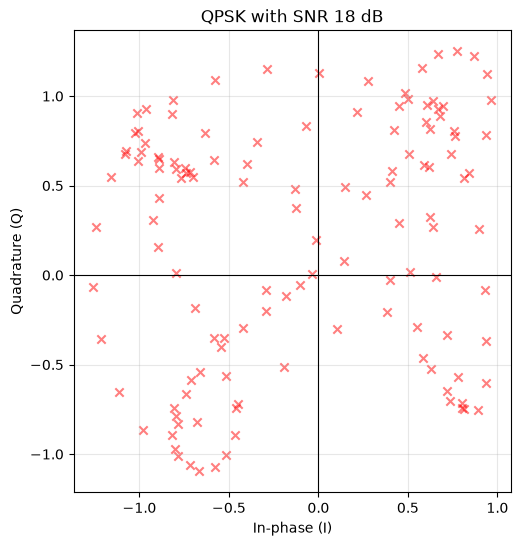

In [94]:
#plotting normalized constellation
plt.figure(figsize=(6, 6))
plt.scatter(
    norm_I,
    norm_Q,
    marker = "x",
    color = "red",
    alpha = 0.5 
)

#axes
plt.axhline(0, color="black", linewidth=0.8)   # axis at Q = 0
plt.axvline(0, color="black", linewidth=0.8)   # axis at I = 0
plt.grid(alpha=0.3)

plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title(f"{mod} with SNR {snr} dB")

plt.axis("equal")   # same scale on I and Q
plt.gca().set_aspect("equal", adjustable="box")

In [95]:
# Extracting amplitude and phase
z = norm_I + 1j*norm_Q
amplitude = np.abs(z)
phase = np.angle(z)

z.shape, amplitude.shape, phase.shape

((1, 128), (1, 128), (1, 128))

Text(0.5, 0, 'Sample index')

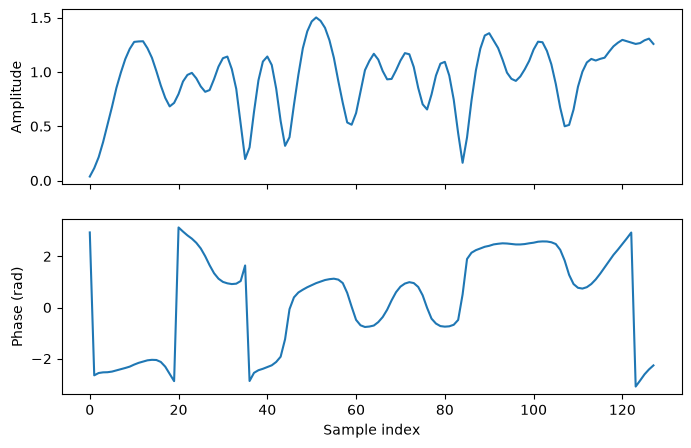

In [96]:
# plotting phase and amplitude
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

ax1.plot(amplitude[0])
ax1.set_ylabel("Amplitude")

ax2.plot(phase[0])
ax2.set_ylabel("Phase (rad)")
ax2.set_xlabel("Sample index")

# 3. Classification

We start from the easiest case, SNR = 18 dB, then extend the model to lower SNRs.

In [103]:
# setting up parameters

SEED = 1
SNR = 18

TRAIN_RATIO = 0.55
VAL_RATIO = 0.15
TEST_RATIO = 0.3


In [ ]:
# setting up frames and labels
frames_list = []
labels_list = []

for label, m in enumerate(unique_mods):                 
    frames = df[(m, SNR)]   # (1000, 2, 128)
    frames_list.append(frames)
    labels_list.append(np.full(len(frames), label))
    
highsnr_frames = np.concatenate(frames_list)       
labels = np.concatenate(labels_list)            

highsnr_frames.shape, labels.shape


((11000, 2, 128), (11000,))

In [ ]:
X = torch.from_numpy(highsnr_frames).float()
y = torch.from_numpy(labels).long()





((11000, 2, 128), (11000,))